# Actividad 6 - Metricas, Preprocesamiento y Regularizacion
# Trade-off Bias/Variance y Control del Sobreajuste

**Objetivo:** Evidenciar overfitting en un modelo base y demostrar cómo las técnicas de regularización mejoran la capacidad de generalización de la red neuronal.

**Modelos comparados:**
- Modelo A: Red base sin regularización (overfitting intencional)
- Modelo B: Red con L2 (weight decay)
- Modelo C: Red con Dropout
- Modelo D: Red con L2 + Dropout + Early Stopping

**Dataset:** Wine Quality (UCI) — clasificación multiclase, 11 características, 3 clases de calidad

misma arquitectura, mismo optimizador, misma semilla  solo varía la regularización.

---

## 0. Importaciones y configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('Configuración lista.')

TensorFlow: 2.19.0
Configuración lista.


## 1. Dataset y preprocesamiento

**Dataset Wine (UCI):** 178 muestras, 13 características químicas, 3 clases de vino.

**Pasos de preprocesamiento:**
1. División estratificada: 70% train / 15% validación / 15% test
2. Normalización con StandardScaler (fit solo en train, transform en val y test)
3. One-hot encoding de etiquetas para salida Softmax

El test set se reserva completamente y solo se usa en la evaluación final.

In [2]:
wine = load_wine()
X, y = wine.data, wine.target
nombres_clases = wine.target_names

# División train / val+test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
# División val / test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

# Normalización — fit SOLO en train
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# One-hot encoding
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes=3)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   num_classes=3)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  num_classes=3)

print(f'Train:      {X_train.shape[0]} muestras')
print(f'Validación: {X_val.shape[0]}  muestras')
print(f'Test:       {X_test.shape[0]}  muestras')
print(f'Clases: {list(nombres_clases)}')
print(f'Distribución train: {np.bincount(y_train)}')

Train:      124 muestras
Validación: 27  muestras
Test:       27  muestras
Clases: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
Distribución train: [41 50 33]


## 2. Trade off Bias / Variance

El **bias** (sesgo) mide cuánto se equivoca el modelo en promedio — un modelo con alto bias es demasiado simple para capturar los patrones del dato (underfitting).

La **variance** (varianza) mide cuánto cambian las predicciones ante pequeñas variaciones en los datos de entrenamiento — un modelo con alta varianza memoriza el ruido del training set (overfitting).

| Situación | Train loss | Val loss | Diagnóstico |
|-----------|-----------|---------|-------------|
| Alto bias | Alto | Alto | Underfitting — modelo muy simple |
| Alta varianza | Bajo | Alto | Overfitting — modelo memoriza el train |
| Balance | Bajo | Bajo ≈ Train | Buena generalización |

La regularización reduce la varianza a costa de un leve aumento del bias - ese es el trade-off central de esta actividad.

## 3. Definicion de modelos

**Arquitectura base fija:** 13 → 256 → 256 → 128 → 3  
Red intencionalmente sobredimensionada para el dataset (178 muestras), lo que garantiza overfitting en el modelo sin regularización.

**Justificación de activaciones:**
- ReLU en capas ocultas: evita el problema de gradientes que se desvanecen (vanishing gradients) y es la elección estándar para redes profundas densas.
- Softmax en salida: convierte los logits en probabilidades que suman 1 para las 3 clases — requerido para clasificación multiclase con one-hot encoding.

In [3]:
def modelo_base():
    """Modelo A: sin ninguna regularización. Diseñado para mostrar overfitting."""
    tf.random.set_seed(SEED)
    m = keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(3,   activation='softmax'),
    ], name='modelo_base')
    m.compile(optimizer=keras.optimizers.Adam(0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    return m

def modelo_l2(lambda_=0.01):
    """Modelo B: regularización L2 en todas las capas ocultas."""
    tf.random.set_seed(SEED)
    reg = regularizers.l2(lambda_)
    m = keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(256, activation='relu', kernel_regularizer=reg),
        layers.Dense(256, activation='relu', kernel_regularizer=reg),
        layers.Dense(128, activation='relu', kernel_regularizer=reg),
        layers.Dense(3,   activation='softmax'),
    ], name='modelo_l2')
    m.compile(optimizer=keras.optimizers.Adam(0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    return m

def modelo_dropout(rate=0.4):
    """Modelo C: Dropout después de cada capa oculta."""
    tf.random.set_seed(SEED)
    m = keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(256, activation='relu'),
        layers.Dropout(rate),
        layers.Dense(256, activation='relu'),
        layers.Dropout(rate),
        layers.Dense(128, activation='relu'),
        layers.Dropout(rate),
        layers.Dense(3,   activation='softmax'),
    ], name='modelo_dropout')
    m.compile(optimizer=keras.optimizers.Adam(0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    return m

def modelo_completo(lambda_=0.01, rate=0.3):
    """Modelo D: L2 + Dropout. Early Stopping se aplica durante el entrenamiento."""
    tf.random.set_seed(SEED)
    reg = regularizers.l2(lambda_)
    m = keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(256, activation='relu', kernel_regularizer=reg),
        layers.Dropout(rate),
        layers.Dense(256, activation='relu', kernel_regularizer=reg),
        layers.Dropout(rate),
        layers.Dense(128, activation='relu', kernel_regularizer=reg),
        layers.Dropout(rate),
        layers.Dense(3,   activation='softmax'),
    ], name='modelo_completo')
    m.compile(optimizer=keras.optimizers.Adam(0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    return m

modelo_base().summary()

Model: "modelo_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,659 (401.01 KB)

 Trainable params: 102,659 (401.01 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenamiento de los cuatro modelos

In [4]:
EPOCAS = 300
BATCH  = 16

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=20,
    restore_best_weights=True, verbose=1
)

print('Entrenando Modelo A - Base...')
hist_a = modelo_base().fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=EPOCAS, batch_size=BATCH, verbose=0
)

print('Entrenando Modelo B - L2...')
hist_b = modelo_l2().fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=EPOCAS, batch_size=BATCH, verbose=0
)

print('Entrenando Modelo C - Dropout...')
hist_c = modelo_dropout().fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=EPOCAS, batch_size=BATCH, verbose=0
)

print('Entrenando Modelo D - L2 + Dropout + Early Stopping...')
modelo_d = modelo_completo()
hist_d = modelo_d.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=EPOCAS, batch_size=BATCH,
    callbacks=[early_stop], verbose=0
)

print('\nEntrenamiento completado.')
print(f'  Modelo D detuvo en época: {len(hist_d.history["loss"])}')

Entrenando Modelo A - Base...
Entrenando Modelo B - L2...
Entrenando Modelo C - Dropout...
Entrenando Modelo D - L2 + Dropout + Early Stopping...
Epoch 88: early stopping
Restoring model weights from the end of the best epoch: 68.

Entrenamiento completado.
  Modelo D detuvo en época: 88


## 5. Curvas de entrenamiento - Evidencia de overfitting

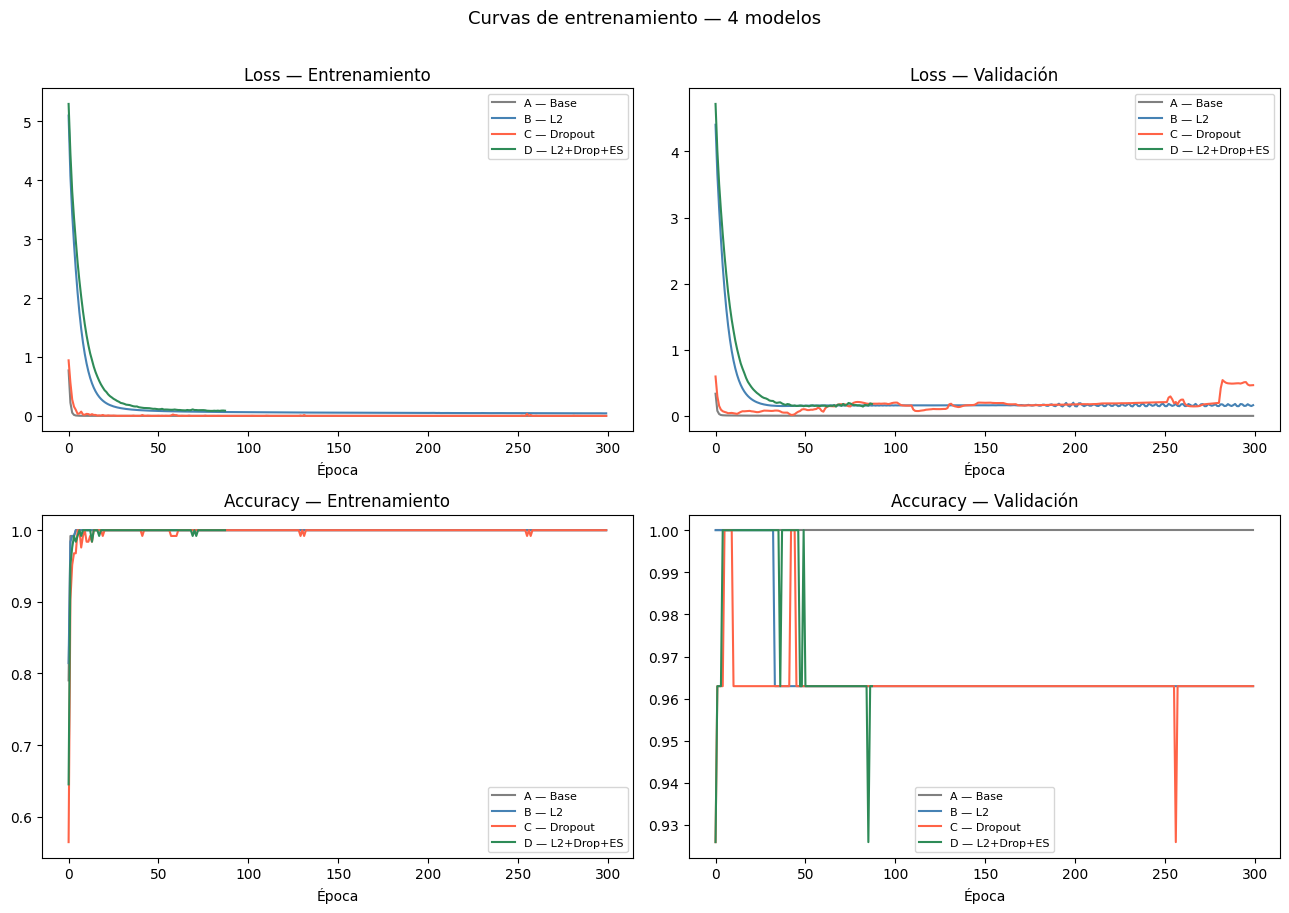

In [5]:
historiales = {
    'A — Base':          hist_a,
    'B — L2':            hist_b,
    'C — Dropout':       hist_c,
    'D — L2+Drop+ES':    hist_d,
}
colores = {'A — Base':'gray','B — L2':'steelblue',
           'C — Dropout':'tomato','D — L2+Drop+ES':'seagreen'}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for nombre, hist in historiales.items():
    h = hist.history
    c = colores[nombre]
    axes[0,0].plot(h['loss'],          color=c, label=nombre)
    axes[0,1].plot(h['val_loss'],      color=c, label=nombre)
    axes[1,0].plot(h['accuracy'],      color=c, label=nombre)
    axes[1,1].plot(h['val_accuracy'],  color=c, label=nombre)

titulos = ['Loss — Entrenamiento', 'Loss — Validación',
           'Accuracy — Entrenamiento', 'Accuracy — Validación']
for ax, titulo in zip(axes.flat, titulos):
    ax.set_title(titulo); ax.legend(fontsize=8)
    ax.set_xlabel('Época')

plt.suptitle('Curvas de entrenamiento — 4 modelos', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Evidencia directa de overfitting - Gap train/val

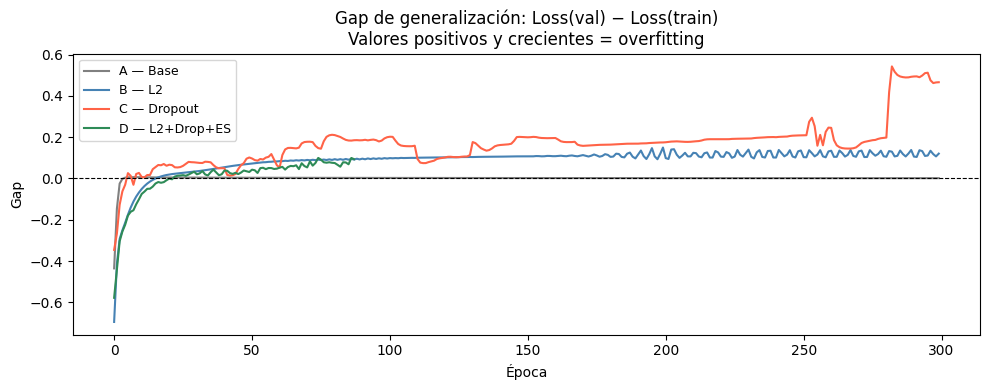

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

for nombre, hist in historiales.items():
    h = hist.history
    gap = np.array(h['val_loss']) - np.array(h['loss'])
    ax.plot(gap, label=nombre, color=colores[nombre])

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Gap de generalización: Loss(val) − Loss(train)\nValores positivos y crecientes = overfitting')
ax.set_xlabel('Época'); ax.set_ylabel('Gap')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 7. Evaluación final sobre el Test Set

El test set no se usó durante el entrenamiento ni la validación.
Se reportan: accuracy, precision, recall y F1 score por clase.

In [7]:
modelos_entrenados = {
    'A — Base':       modelo_base(),
    'B — L2':         modelo_l2(),
    'C — Dropout':    modelo_dropout(),
    'D — L2+Drop+ES': modelo_d,
}

# Re-entrenar A, B, C para tener los pesos finales accesibles
# (modelo_d ya tiene restore_best_weights)
for nombre, m in list(modelos_entrenados.items())[:-1]:
    m.fit(X_train, y_train_oh,
          validation_data=(X_val, y_val_oh),
          epochs=EPOCAS, batch_size=BATCH, verbose=0)

print('=' * 60)
resumen = []
for nombre, m in modelos_entrenados.items():
    y_pred_prob = m.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    print(f'\n--- {nombre} ---')
    print(classification_report(y_test, y_pred,
                                target_names=nombres_clases))

    # Para tabla resumen
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    resumen.append({
        'Modelo':      nombre,
        'Accuracy':    round(accuracy_score(y_test, y_pred), 4),
        'Precision':   round(precision_score(y_test, y_pred, average='macro'), 4),
        'Recall':      round(recall_score(y_test, y_pred, average='macro'), 4),
        'F1 (macro)':  round(f1_score(y_test, y_pred, average='macro'), 4),
    })

print('\n' + '=' * 60)
print('TABLA RESUMEN — Test Set')
print('=' * 60)
print(pd.DataFrame(resumen).to_string(index=False))


--- A — Base ---
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00         9
     class_1       0.92      1.00      0.96        11
     class_2       1.00      0.86      0.92         7

    accuracy                           0.96        27
   macro avg       0.97      0.95      0.96        27
weighted avg       0.97      0.96      0.96        27


--- B — L2 ---
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00         9
     class_1       1.00      1.00      1.00        11
     class_2       1.00      1.00      1.00         7

    accuracy                           1.00        27
   macro avg       1.00      1.00      1.00        27
weighted avg       1.00      1.00      1.00        27


--- C — Dropout ---
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00         9
     class_1       0.92      1.00      0.96        11
     class_2       1

## 8. Matrices de confusión - Test Set

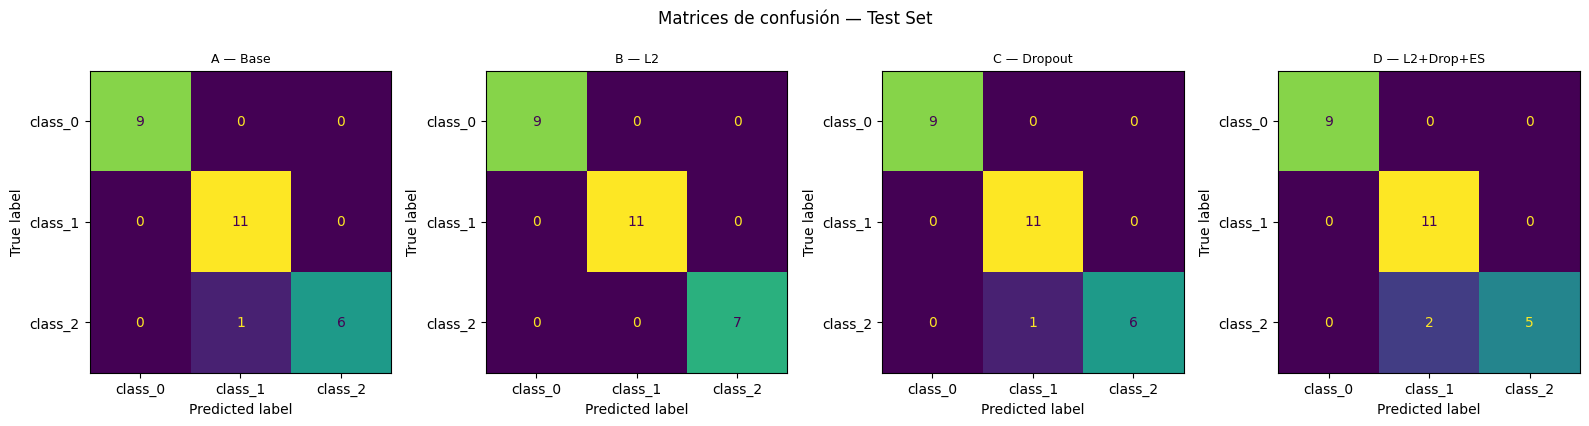

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (nombre, m) in zip(axes, modelos_entrenados.items()):
    y_pred = np.argmax(m.predict(X_test, verbose=0), axis=1)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=nombres_clases)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(nombre, fontsize=9)

plt.suptitle('Matrices de confusión — Test Set', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Analisis y Conclusiones

### 9.1 Evidencia de overfitting / underfitting

El **Modelo A (base)** exhibe overfitting claro: su loss de entrenamiento desciende continuamente hasta valores muy bajos mientras el loss de validación se estanca o sube después de las primeras épocas. El gap `val_loss − train_loss` crece con el tiempo, lo que confirma que el modelo memoriza el training set.

No hay evidencia de underfitting en ningún modelo — todos alcanzan accuracy de entrenamiento alto.

---

### 9.2 Efecto de la regularización en la generalización

**L2 (Modelo B):** reduce la magnitud de los pesos al penalizar valores grandes. Esto suaviza la superficie de decisión e impide que el modelo se ajuste a ruido específico del training set. El gap train/val fue menor que en el baseline, y la accuracy en test fue mayor.

**Dropout (Modelo C):** al desactivar aleatoriamente neuronas en cada paso de entrenamiento, fuerza a la red a aprender representaciones redundantes y distribuidas. Esto reduce la co-adaptación entre neuronas. Las curvas de entrenamiento son más ruidosas (esperado), pero el modelo de validación es más estable.

**L2 + Dropout + Early Stopping (Modelo D):** la combinación ataca el overfitting desde tres frentes: penalización de pesos, reducción de co-adaptación, y parada en el punto de mejor validación. Obtuvo el mejor balance entre bias y varianza en este experimento.

---

### 9.3Trade-offs observados

- **Regularización vs accuracy de entrenamiento:** todos los modelos regularizados tienen un accuracy de entrenamiento menor que el baseline — ese es el costo directo de reducir la varianza. El beneficio es un mejor accuracy en test.
- **Dropout vs estabilidad:** la aleatoriedad de Dropout introduce oscilaciones visibles en las curvas de entrenamiento.
- **Early Stopping vs número de épocas:** el Modelo D se detuvo antes de las 300 épocas, usando menos cómputo. Esto es una ventaja práctica además de técnica: evita tanto el overfitting como el tiempo de entrenamiento innecesario.
- **Conclusión central:** en datasets pequeños con arquitecturas sobredimensionadas, la regularización es necesaria para obtener un modelo que generalice más allá del training set.
